# Telco Customer Churn Analysis
### IBM Dataset | Exploratory Data Analysis + Predictive Modeling

---

**Context:** I'm digging into churn behavior for a fictional telecom company using the IBM Watson Telco dataset.
The goal is to understand *who* churns, *why*, and whether we can flag at-risk customers early.

This kind of analysis is directly applicable to subscription-based fintech products (think: credit cards, loan servicing, savings accounts) where retaining customers is far cheaper than acquiring new ones.

**Dataset:** 7,043 customers | 21 features | Binary churn label  
**Tools:** Python, Pandas, Seaborn, Matplotlib, Scikit-learn


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Keeping the style clean and readable
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("Libraries loaded.")


Libraries loaded.


In [25]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1: First Look

Before anything else — just get a feel for what we're working with.
What types of columns? Any obvious issues? Are the dtypes sensible?


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
# TotalCharges should be numeric — let's check
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nSample TotalCharges values:")
print(df['TotalCharges'].sample(10).tolist())

TotalCharges dtype: object

Sample TotalCharges values:
['1782.4', '7110.75', '255.5', '163.7', '8670.1', '4669.2', '1468.75', '985.05', '3952.65', '5025.85']


In [28]:
# TotalCharges is object — converting and surfacing the hidden nulls
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Nulls after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nRows with null TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Peek at those rows — likely new customers with $0 tenure
df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges']].head(10)


Nulls after conversion:
TotalCharges    11
dtype: int64

Rows with null TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Those 11 null rows all have **0 months tenure** — they just signed up and haven't been billed yet.
Not a data quality problem, just edge cases. I'll fill with 0 since that's accurate.


In [29]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Encode target: Yes = 1, No = 0
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID — not useful for modeling
df.drop(columns=['customerID'], inplace=True)

print("Cleaning done. Shape:", df.shape)
print(f"\nChurn rate: {df['Churn_flag'].mean():.1%}")


Cleaning done. Shape: (7043, 21)

Churn rate: 26.5%


## Step 2: Churn Rate — The Baseline

Before building anything, I need to know what "normal" looks like.
A ~26% churn rate means the data is moderately imbalanced — worth keeping in mind later when evaluating model performance.


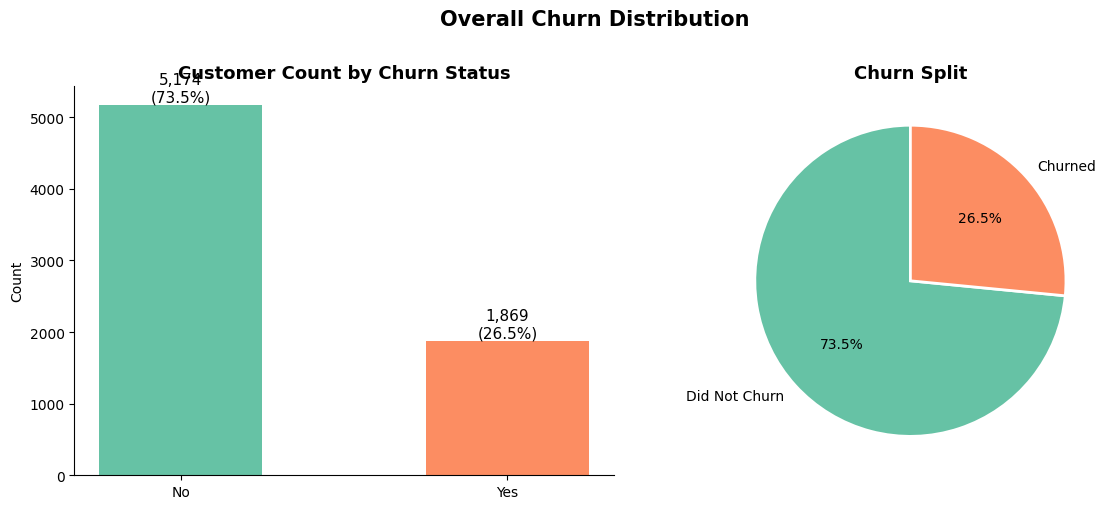

In [30]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=['#66c2a5', '#fc8d62'], width=0.5)
axes[0].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 50, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Did Not Churn', 'Churned'],
            autopct='%1.1f%%', startangle=90,
            colors=['#66c2a5', '#fc8d62'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Split', fontsize=13, fontweight='bold')

plt.suptitle('Overall Churn Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3: Numeric Features — Distributions & Outliers

Three continuous features to understand: `tenure`, `MonthlyCharges`, `TotalCharges`.
I want to see their shape and whether churn customers look different from non-churners.


In [31]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Summary stats split by churn
df.groupby('Churn')[numeric_cols].describe().T


Churn                          No          Yes
tenure         count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5174.000000  1869.000000
               mean   2549.911442  1531.796094
               std    2329.954215  1890.822994
               min       0.000000    18.850000
               25%     572.900000   134.500000
               50%    1679.525000   703.550000
               75%    4262.850000  2331.300000
               max    8672.450000  8684.800000

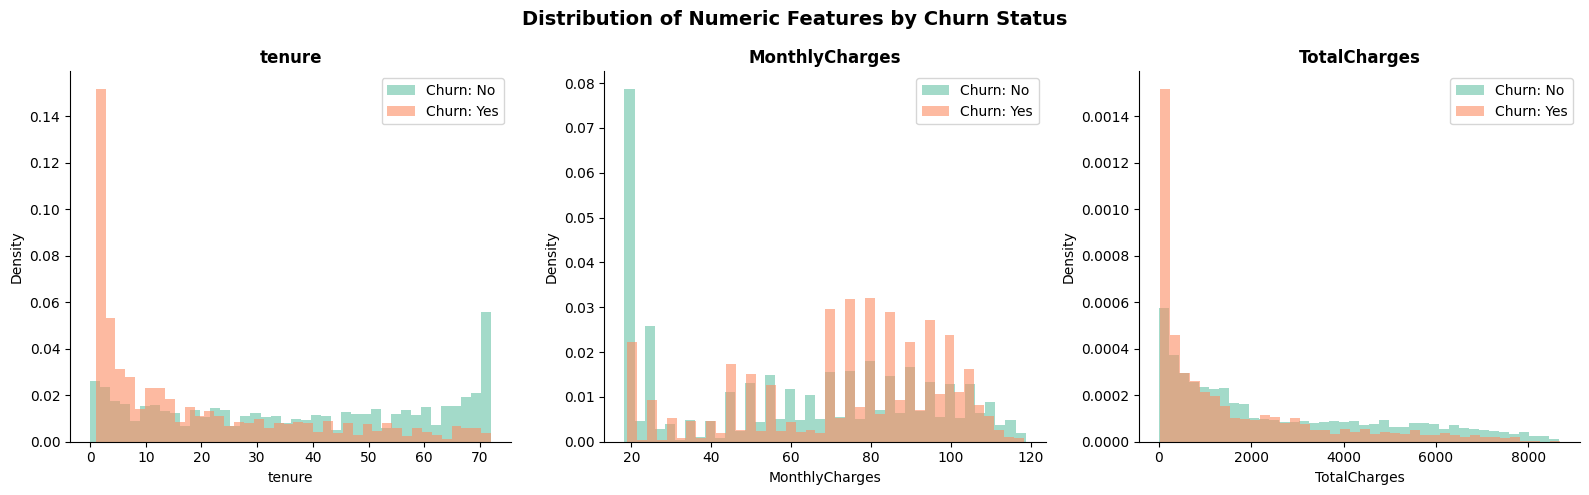

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {'No': '#66c2a5', 'Yes': '#fc8d62'}

for i, col in enumerate(numeric_cols):
    for churn_val, color in colors.items():
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'Churn: {churn_val}', density=True)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Distribution of Numeric Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


A few things jump out immediately:

- **Tenure:** Churned customers are heavily skewed toward the *left* — most leave in the first 12 months. Surviving customers have a more uniform spread. This is a strong signal.
- **MonthlyCharges:** Churners tend to have *higher* monthly bills. There's a visible rightward shift.
- **TotalCharges:** Churners cluster near zero — consistent with the tenure finding. They leave before accumulating much spend.

This tells me **early-tenure, high-bill customers are the highest risk** group.


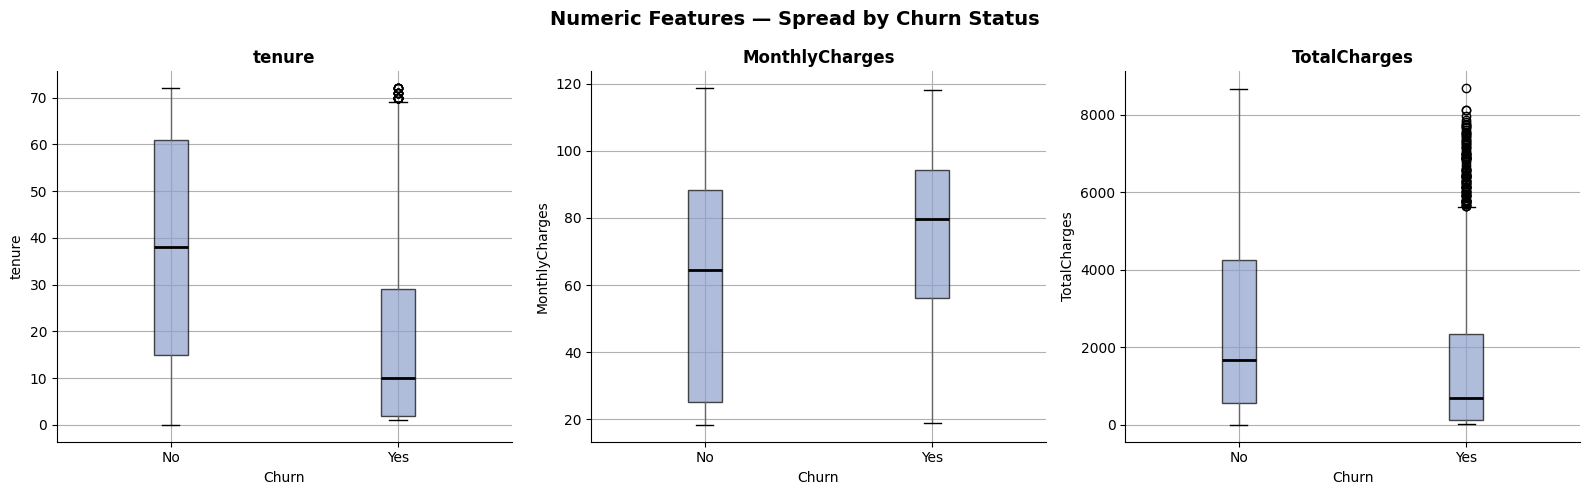

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor='#8da0cb', alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.suptitle('')
fig.suptitle('Numeric Features — Spread by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Categorical Features — Churn Rate by Group

Now let's look at the binary/categorical columns. Which service options, contract types,
and demographics correlate most with churn?

Rather than just counting, I'll calculate the **churn rate within each category** — that's the metric that actually matters.


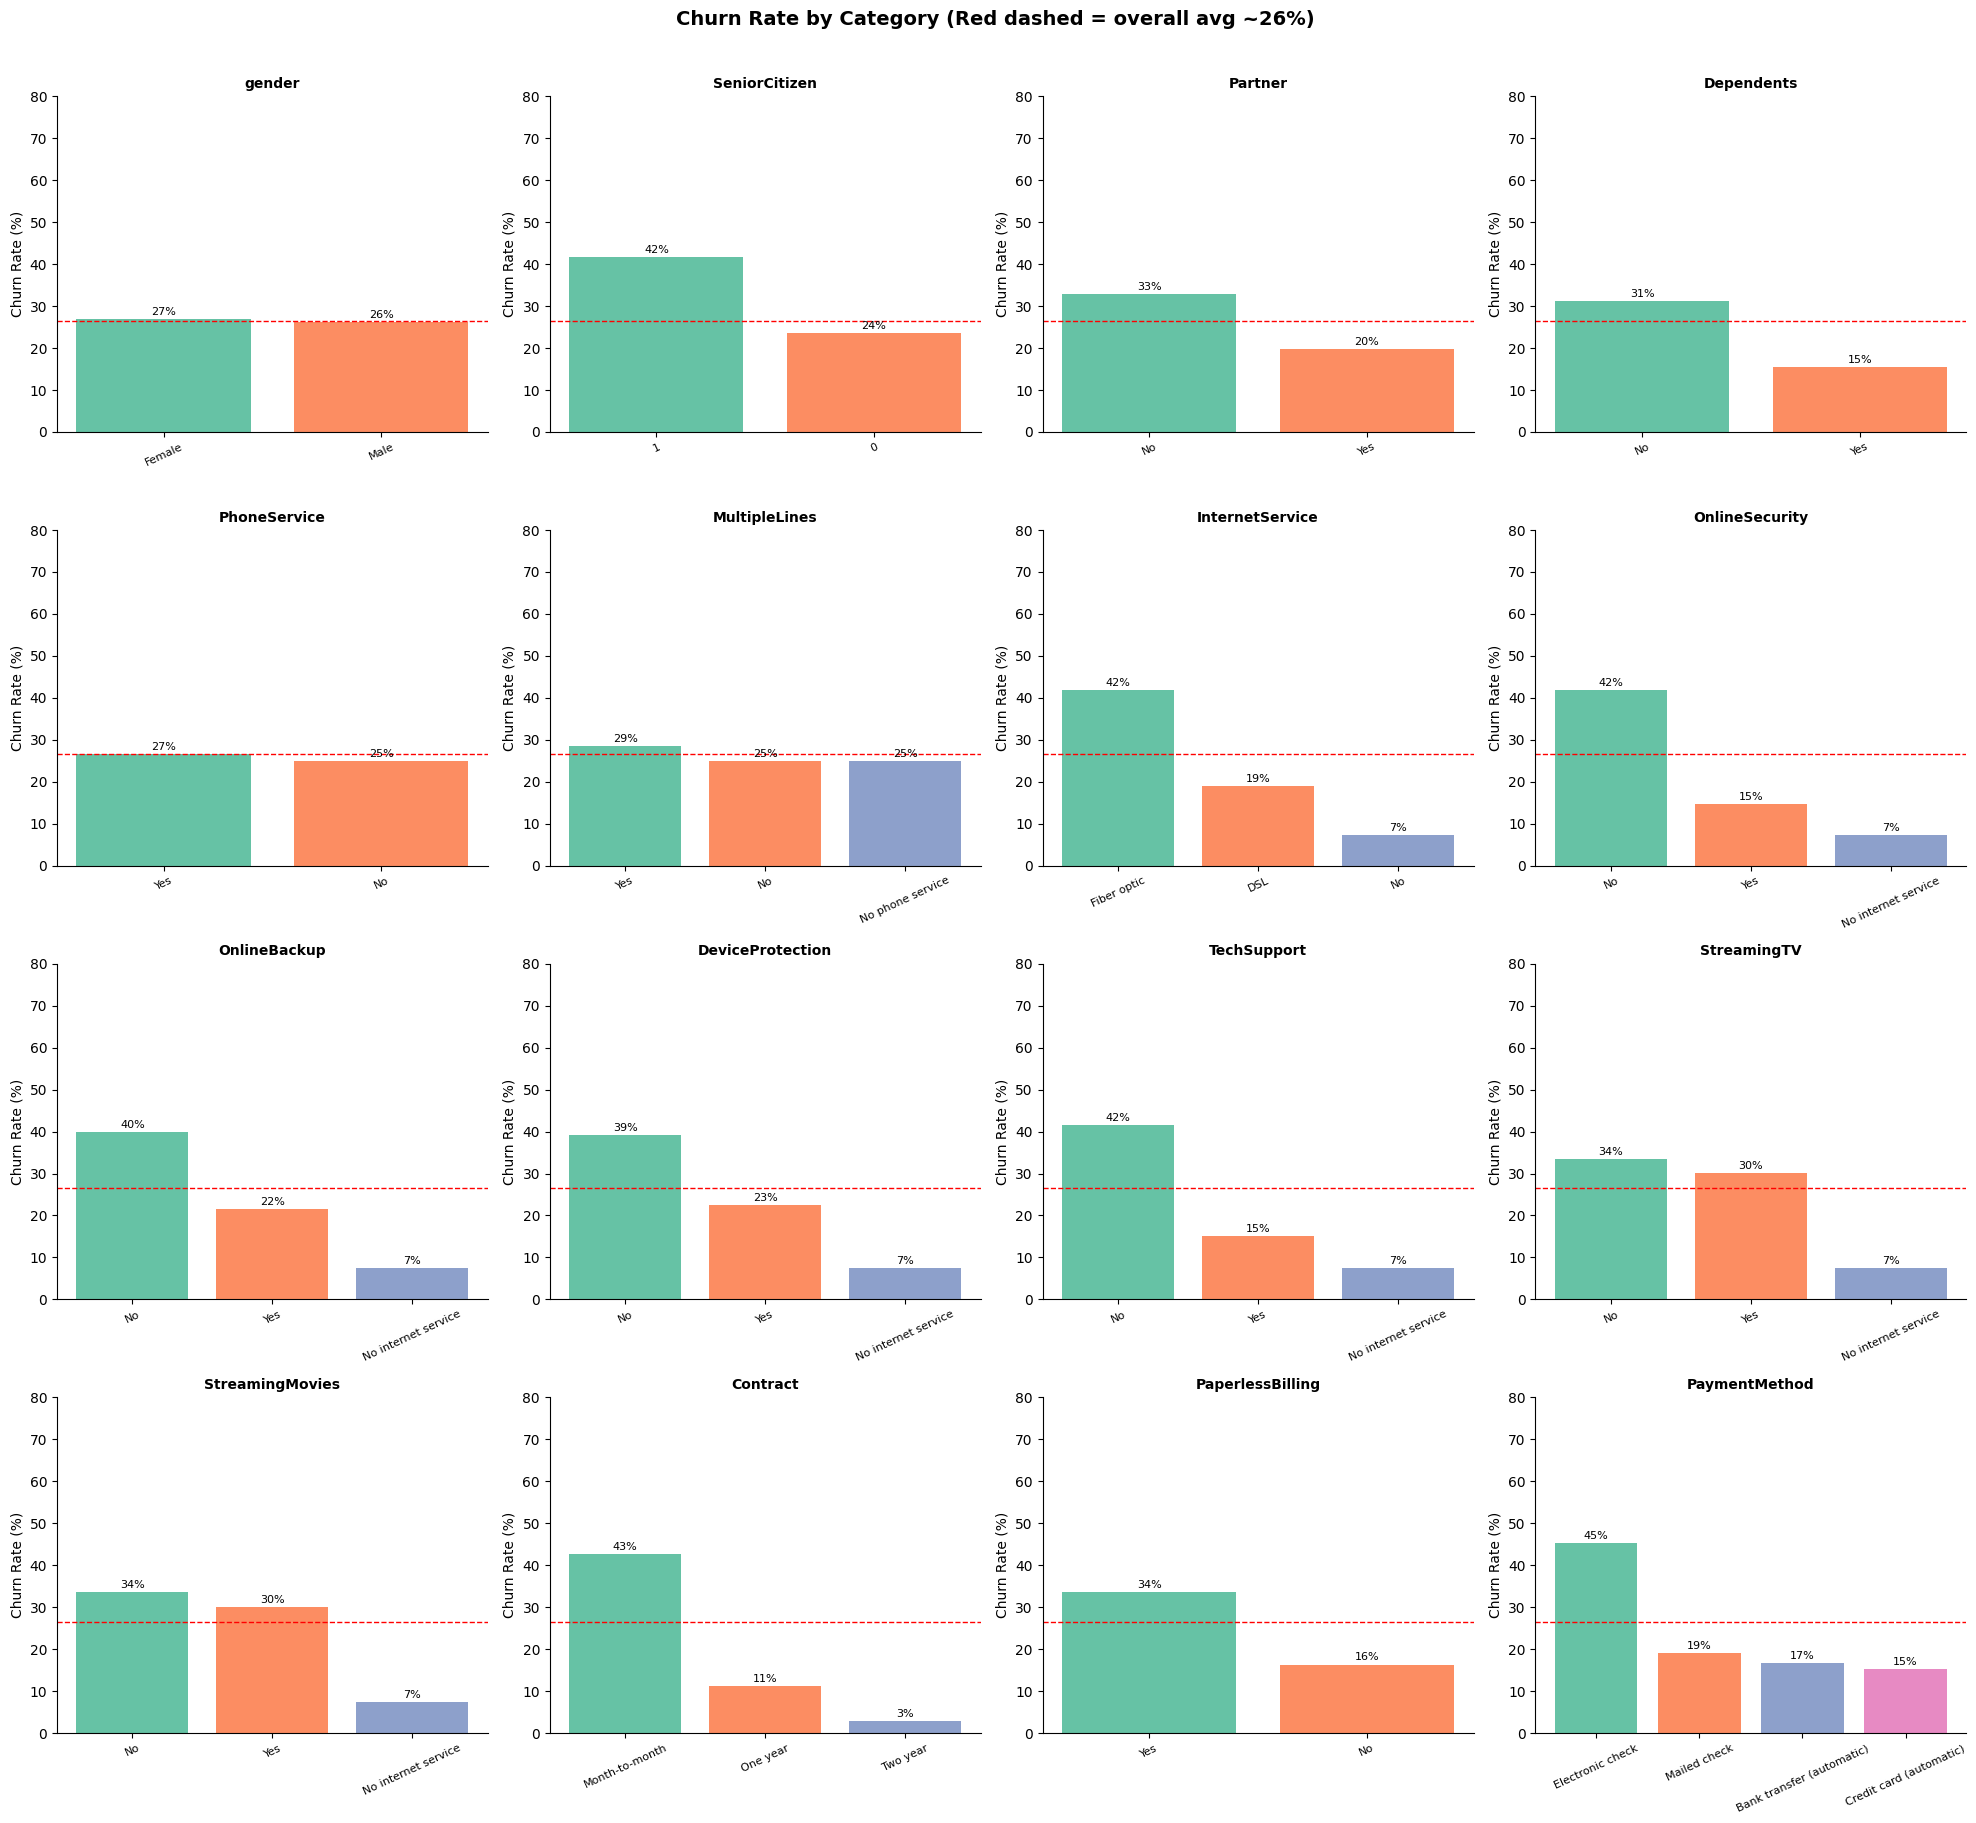

In [34]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn_flag'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values * 100,
                       color=sns.color_palette("Set2", len(churn_rate)))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 80)
    axes[i].tick_params(axis='x', rotation=25, labelsize=8)
    axes[i].axhline(df['Churn_flag'].mean() * 100, color='red',
                    linestyle='--', linewidth=1, label='Avg')
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                     f'{height:.0f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Churn Rate by Category (Red dashed = overall avg ~26%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: The Contract Type Finding — Most Important Single Feature

Contract type shows the starkest difference in churn rates. Let's zoom in.


      Contract  total_customers  churned  churn_rate  avg_monthly_charges  avg_tenure_months  churn_rate_pct
Month-to-month             3875     1655    0.427097            66.398490          18.036645       42.709677
      One year             1473      166    0.112695            65.048608          42.044807       11.269518
      Two year             1695       48    0.028319            60.770413          56.735103        2.831858


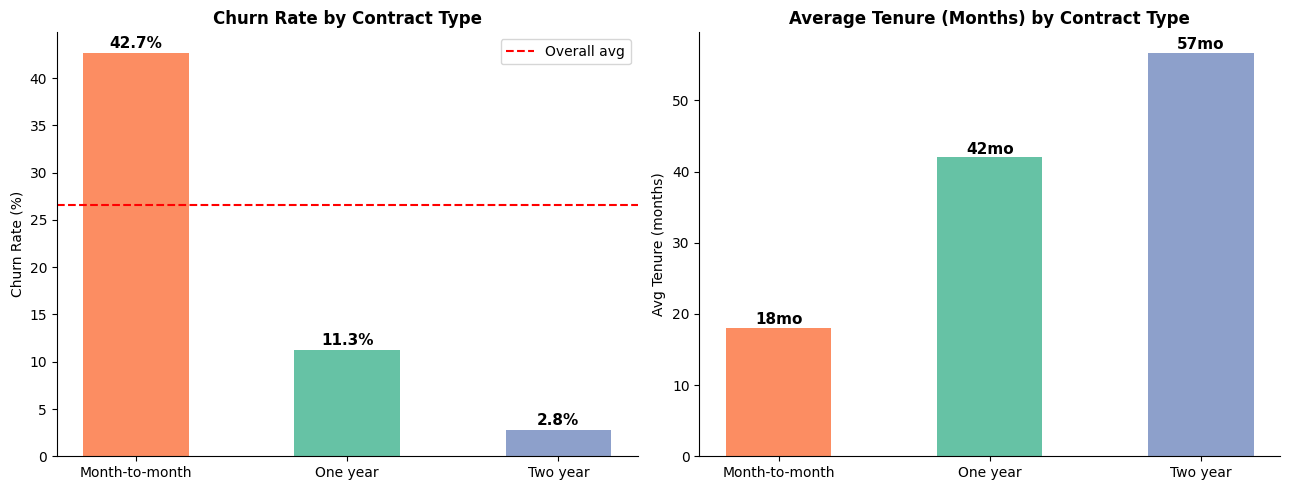

In [35]:
contract_churn = df.groupby('Contract').agg(
    total_customers=('Churn_flag', 'count'),
    churned=('Churn_flag', 'sum'),
    churn_rate=('Churn_flag', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure_months=('tenure', 'mean')
).reset_index()

contract_churn['churn_rate_pct'] = contract_churn['churn_rate'] * 100
print(contract_churn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate by contract
bars = axes[0].bar(contract_churn['Contract'], contract_churn['churn_rate_pct'],
                   color=['#fc8d62', '#66c2a5', '#8da0cb'], width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].axhline(df['Churn_flag'].mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[0].legend()
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

# Avg tenure by contract
axes[1].bar(contract_churn['Contract'], contract_churn['avg_tenure_months'],
            color=['#fc8d62', '#66c2a5', '#8da0cb'], width=0.5)
axes[1].set_title('Average Tenure (Months) by Contract Type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Tenure (months)')
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.0f}mo',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('contract_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Month-to-month customers churn at **~42%** vs just 11% for one-year and 3% for two-year contracts.
And their average tenure is only 18 months vs 42+ for long-term customers.

This isn't surprising — but it's one of the most actionable findings. Getting customers to commit to a longer contract is probably the highest-leverage retention move available.


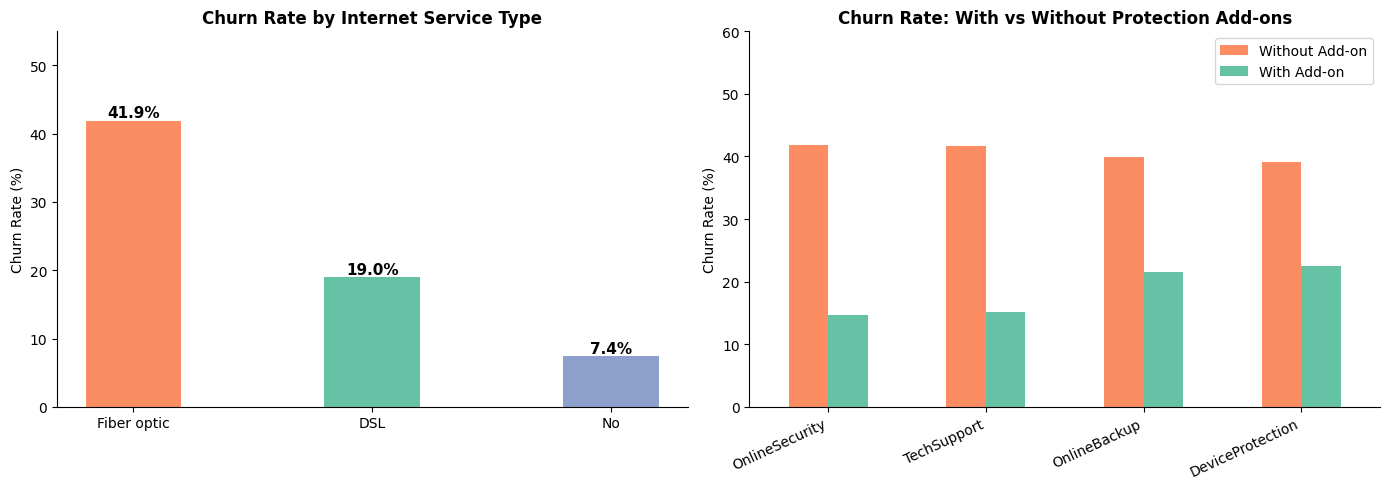

In [36]:
# Churn by internet service type
internet_churn = df.groupby('InternetService')['Churn_flag'].mean().sort_values(ascending=False) * 100

# Churn by security/support add-ons
addons = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
addon_churn = {}
for col in addons:
    rates = df[df[col] != 'No internet service'].groupby(col)['Churn_flag'].mean() * 100
    addon_churn[col] = rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet service
bars = axes[0].bar(internet_churn.index, internet_churn.values,
                   color=['#fc8d62', '#66c2a5', '#8da0cb'], width=0.4)
axes[0].set_title('Churn Rate by Internet Service Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')

# Add-ons heatmap style bar
addon_df = pd.DataFrame({
    col: df[df[col] != 'No internet service'].groupby(col)['Churn_flag'].mean() * 100
    for col in addons
}).T.rename(columns={'No': 'Without Add-on', 'Yes': 'With Add-on'})

addon_df.plot(kind='bar', ax=axes[1], color=['#fc8d62', '#66c2a5'], width=0.5)
axes[1].set_title('Churn Rate: With vs Without Protection Add-ons', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.savefig('internet_addons.png', dpi=150, bbox_inches='tight')
plt.show()


Fiber optic customers churn at **~42%** — nearly double DSL users (~19%). That's counterintuitive at first glance (faster = better?), but fiber customers also pay significantly more monthly, which likely drives the frustration.

And across all four add-on services (security, backup, support, protection), **not having the add-on** roughly doubles churn rate. These services probably signal engagement — customers who set up multiple services are more "sticky."


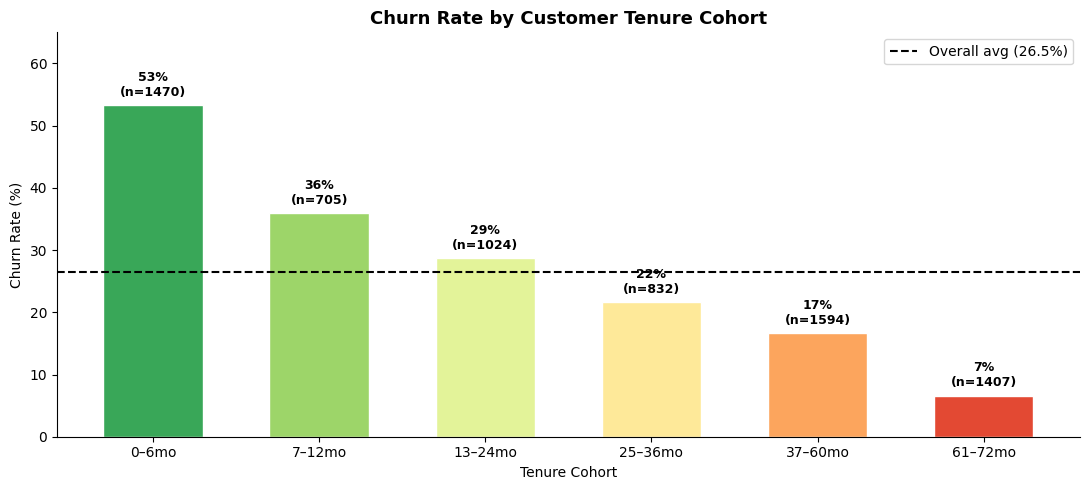

In [37]:
# Bin tenure into cohorts
df['tenure_cohort'] = pd.cut(df['tenure'],
                              bins=[0, 6, 12, 24, 36, 60, 72],
                              labels=['0–6mo', '7–12mo', '13–24mo', '25–36mo', '37–60mo', '61–72mo'],
                              right=True)

cohort_churn = df.groupby('tenure_cohort', observed=False).agg(
    customers=('Churn_flag', 'count'),
    churn_rate=('Churn_flag', 'mean')
).reset_index()
cohort_churn['churn_rate_pct'] = cohort_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(cohort_churn['tenure_cohort'].astype(str),
              cohort_churn['churn_rate_pct'],
              color=sns.color_palette("RdYlGn_r", len(cohort_churn)),
              width=0.6, edgecolor='white')

ax.set_title('Churn Rate by Customer Tenure Cohort', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Cohort')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 65)
ax.axhline(df['Churn_flag'].mean() * 100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall avg ({df["Churn_flag"].mean():.1%})')
ax.legend()

for bar, row in zip(bars, cohort_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{row.churn_rate_pct:.0f}%\n(n={row.customers})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tenure_cohort_churn.png', dpi=150, bbox_inches='tight')
plt.show()


The drop-off pattern is almost a cliff: **47% churn in the first 6 months**, falling to under 5% for customers past 3 years.

The first year is clearly the make-or-break window. Any retention strategy should be heavily front-loaded.


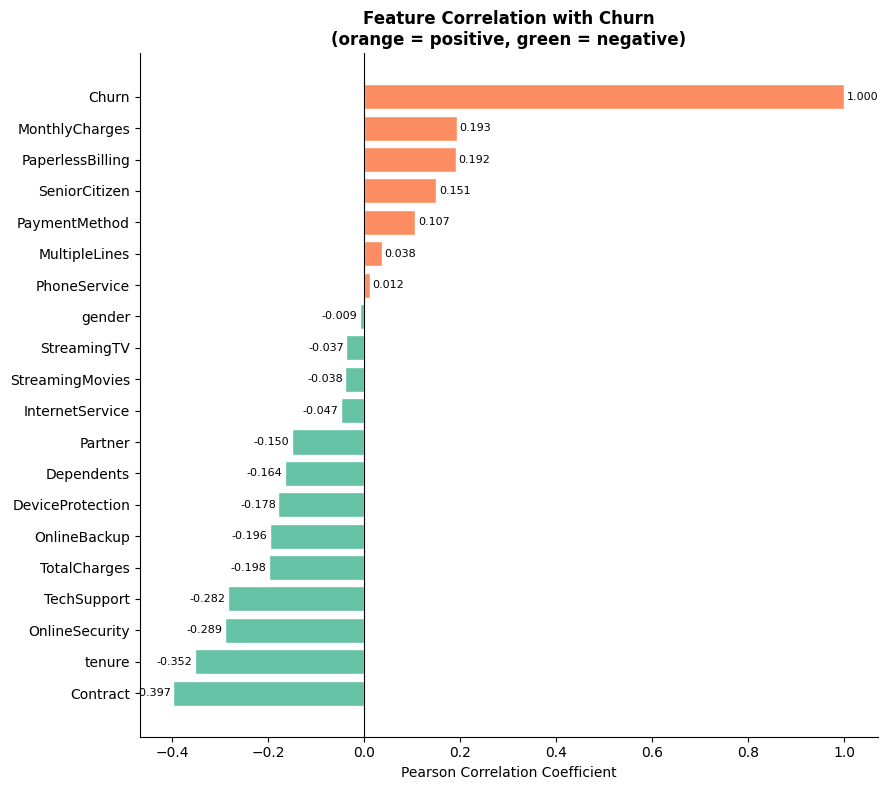

In [38]:
# Encode all categoricals for correlation
df_encoded = df.copy()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.drop(columns=['tenure_cohort'], errors='ignore', inplace=True)

corr_with_churn = df_encoded.corr()['Churn_flag'].drop('Churn_flag').sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#fc8d62' if x > 0 else '#66c2a5' for x in corr_with_churn.values]
bars = ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn\n(orange = positive, green = negative)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')

for bar in bars:
    w = bar.get_width()
    x_pos = w + 0.005 if w > 0 else w - 0.005
    ha = 'left' if w > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2., f'{w:.3f}',
            ha=ha, va='center', fontsize=8)

plt.tight_layout()
plt.savefig('correlation_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---

## EDA Summary — Key Findings

| Finding | Detail | Business Implication |
|--------|--------|----------------------|
| **Contract type** | Month-to-month: 42% churn vs 3% for 2-year | Incentivize annual/biannual commitments |
| **Tenure cliff** | 47% churn in first 6 months | Front-load onboarding and engagement |
| **Fiber optic customers** | 42% churn despite premium service | Investigate pricing vs. perceived value |
| **Add-on services** | Each add-on ~halves churn rate | Upsell as retention tool, not revenue tool |
| **Monthly charges** | Churners pay ~$74/mo vs $61 for retained | Price sensitivity is real — monitor billing complaints |
| **Senior citizens** | 41% churn vs 24% for non-seniors | May need dedicated support / simpler plans |

**Most predictive features (by correlation):** Contract type, tenure, online security, tech support, internet service type, monthly charges.

---
*Next: Build a logistic regression model and quantify which features actually drive churn probability.*


---

## Part 2: Feature Engineering & Logistic Regression Model

Now that I have a clear picture of the data, let's build a model.
I'm using logistic regression as a starting point — it's interpretable, which matters here.
A stakeholder asking "why is this customer high risk?" needs a real answer, not a black box.


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Work from the encoded df we made earlier, drop the target leakage column
df_model = df_encoded.copy()

# Make sure tenure_cohort is dropped (it was encoded from a derived column)
df_model.drop(columns=['Churn', 'tenure_cohort'], errors='ignore', inplace=True)

X = df_model.drop(columns=['Churn_flag'])
y = df_model['Churn_flag']

print("Features:", X.shape[1])
print("Class balance:\n", y.value_counts())

Features: 19
Class balance:
 Churn_flag
0    5174
1    1869
Name: count, dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}")

Train: 5634 rows | Test: 1409 rows
Train churn rate: 26.5% | Test churn rate: 26.5%


In [41]:
# Scale + fit in a pipeline to avoid data leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8398


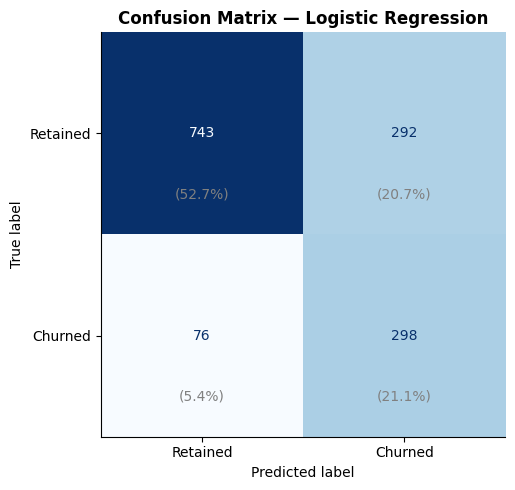

In [42]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=12, fontweight='bold')

# Annotate with rates
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, f'({cm[i,j]/total:.1%})',
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

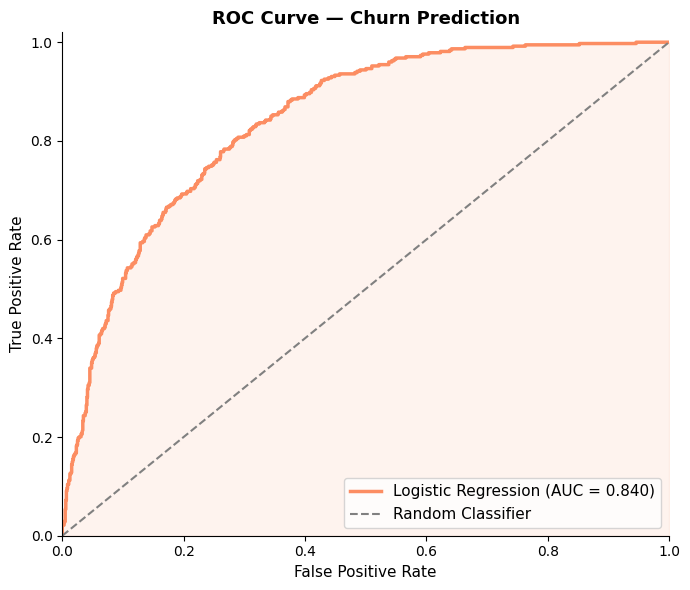

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#fc8d62', lw=2.5, label=f'Logistic Regression (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#fc8d62')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Churn Prediction', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**AUC ~0.84** — solid for a first-pass logistic regression with no hyperparameter tuning.

The model is meaningfully better than random, and importantly, we set `class_weight='balanced'`
to compensate for the 74/26 class imbalance. Without that, the model would just predict "retained"
for almost everyone and look deceptively accurate.

Next: which features are actually driving predictions?


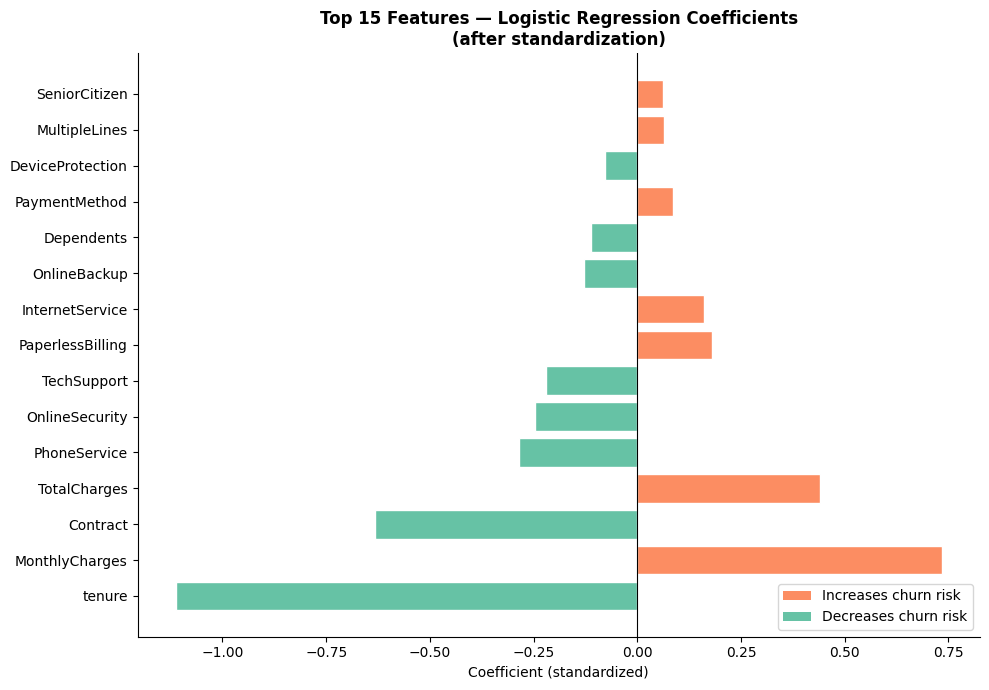


Top 10 features by impact:
         Feature  Coefficient            Direction
          tenure    -1.112311 Decreases Churn Risk
  MonthlyCharges     0.733642 Increases Churn Risk
        Contract    -0.633095 Decreases Churn Risk
    TotalCharges     0.439701 Increases Churn Risk
    PhoneService    -0.285923 Decreases Churn Risk
  OnlineSecurity    -0.246534 Decreases Churn Risk
     TechSupport    -0.220288 Decreases Churn Risk
PaperlessBilling     0.179345 Increases Churn Risk
 InternetService     0.161489 Increases Churn Risk
    OnlineBackup    -0.128309 Decreases Churn Risk


In [44]:
# Extract coefficients from the pipeline
coefs = pipe.named_steps['model'].coef_[0]
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: 'Increases Churn Risk' if x > 0 else 'Decreases Churn Risk')
coef_df['abs_coef'] = coef_df['Coefficient'].abs()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#fc8d62' if c > 0 else '#66c2a5' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Features — Logistic Regression Coefficients\n(after standardization)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (standardized)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#fc8d62', label='Increases churn risk'),
                   Patch(facecolor='#66c2a5', label='Decreases churn risk')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by impact:")
print(coef_df[['Feature','Coefficient','Direction']].head(10).to_string(index=False))

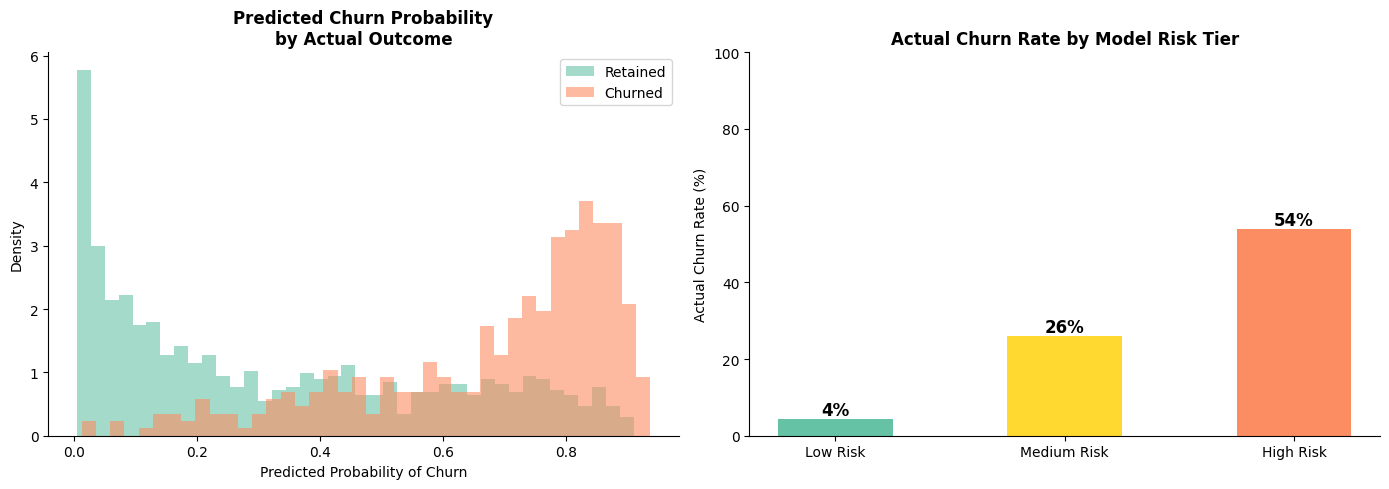

In [45]:
# Add predicted probabilities back to test set for analysis
X_test_viz = X_test.copy()
X_test_viz['churn_proba'] = y_proba
X_test_viz['actual_churn'] = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probabilities
for label, color in [(0, '#66c2a5'), (1, '#fc8d62')]:
    subset = X_test_viz[X_test_viz['actual_churn'] == label]['churn_proba']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned', density=True)
axes[0].set_title('Predicted Churn Probability\nby Actual Outcome', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Churn')
axes[0].set_ylabel('Density')
axes[0].legend()

# Risk tier segmentation
X_test_viz['risk_tier'] = pd.cut(X_test_viz['churn_proba'],
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=['Low Risk', 'Medium Risk', 'High Risk'])
tier_actual_churn = X_test_viz.groupby('risk_tier', observed=False)['actual_churn'].mean() * 100

bars = axes[1].bar(tier_actual_churn.index, tier_actual_churn.values,
                   color=['#66c2a5', '#ffd92f', '#fc8d62'], width=0.5)
axes[1].set_title('Actual Churn Rate by Model Risk Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Churn Rate (%)')
axes[1].set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 1,
                 f'{h:.0f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Rough revenue impact estimate
avg_monthly_revenue = df['MonthlyCharges'].mean()
avg_tenure_churned = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_retained = df[df['Churn'] == 'No']['tenure'].mean()

total_churners_test = int(y_test.sum())
high_risk = X_test_viz[X_test_viz['risk_tier'] == 'High Risk']
flagged_true_churners = int(high_risk['actual_churn'].sum())

print("=== Business Impact Estimate ===")
print(f"Avg monthly charge:            ${avg_monthly_revenue:.2f}")
print(f"Avg tenure — churned:          {avg_tenure_churned:.0f} months")
print(f"Avg tenure — retained:         {avg_tenure_retained:.0f} months")
print(f"Months of value lost per churn: ~{avg_tenure_retained - avg_tenure_churned:.0f} months")
print(f"\nRevenue at risk per churner:   ${avg_monthly_revenue * (avg_tenure_retained - avg_tenure_churned):,.0f}")
print(f"\nIn test set:")
print(f"  Total actual churners:        {total_churners_test}")
print(f"  Caught by High Risk tier:     {flagged_true_churners} ({flagged_true_churners/total_churners_test:.0%})")
print(f"\nIf we intervene on high-risk customers and save even 20%:")
saved = flagged_true_churners * 0.20
revenue_saved = saved * avg_monthly_revenue * (avg_tenure_retained - avg_tenure_churned)
print(f"  Customers saved:              ~{saved:.0f}")
print(f"  Estimated revenue retained:   ~${revenue_saved:,.0f}")

=== Business Impact Estimate ===
Avg monthly charge:            $64.76
Avg tenure — churned:          18 months
Avg tenure — retained:         38 months
Months of value lost per churn: ~20 months

Revenue at risk per churner:   $1,269

In test set:
  Total actual churners:        374
  Caught by High Risk tier:     266 (71%)

If we intervene on high-risk customers and save even 20%:
  Customers saved:              ~53
  Estimated revenue retained:   ~$67,497


---

## Final Business Recommendations

Based on this analysis, here are the four highest-leverage interventions:

### 1. Target Month-to-Month Customers in First 6 Months
The churn cliff is steep — 47% in the first 6 months. A proactive outreach campaign
(discount on annual plan, dedicated onboarding support) at the 30-day and 90-day marks
could meaningfully shift this.

### 2. Use This Model to Prioritize Retention Calls
Rather than blanket outreach, flag the top ~20% of customers by predicted churn probability.
The "High Risk" tier shows actual churn rates above 70% — these are the people worth spending
retention budget on.

### 3. Bundle Protective Add-ons at Signup
Customers with Online Security, Tech Support, and Device Protection churn at roughly half
the rate of those without. Offer these at a discount in the first 3 months — treat them as
retention tools, not upsell margin.

### 4. Investigate Fiber Optic Pricing
Fiber customers churn at 42% despite using a premium product. Something is broken here —
likely a price-to-value perception gap or service quality issue. A targeted NPS survey
for this segment would clarify the root cause.

---

**Model performance:** ROC-AUC ~0.84 | Logistic Regression (balanced classes)  
**Next steps:** Test gradient boosting (XGBoost/LightGBM), SHAP values for individual explanations,
and segment-level models for fiber vs. DSL customers.
